## 01. Stacking

Stacking은 여러 기본 모델의 예측 결과를 다시 하나의 최종 모델이 학습하는 앙상블 방식임.  
Voting이 예측을 단순히 투표하거나 평균내는 방식이라면, Stacking은 **예측을 합치는 방법 자체를 데이터에서 학습**함.

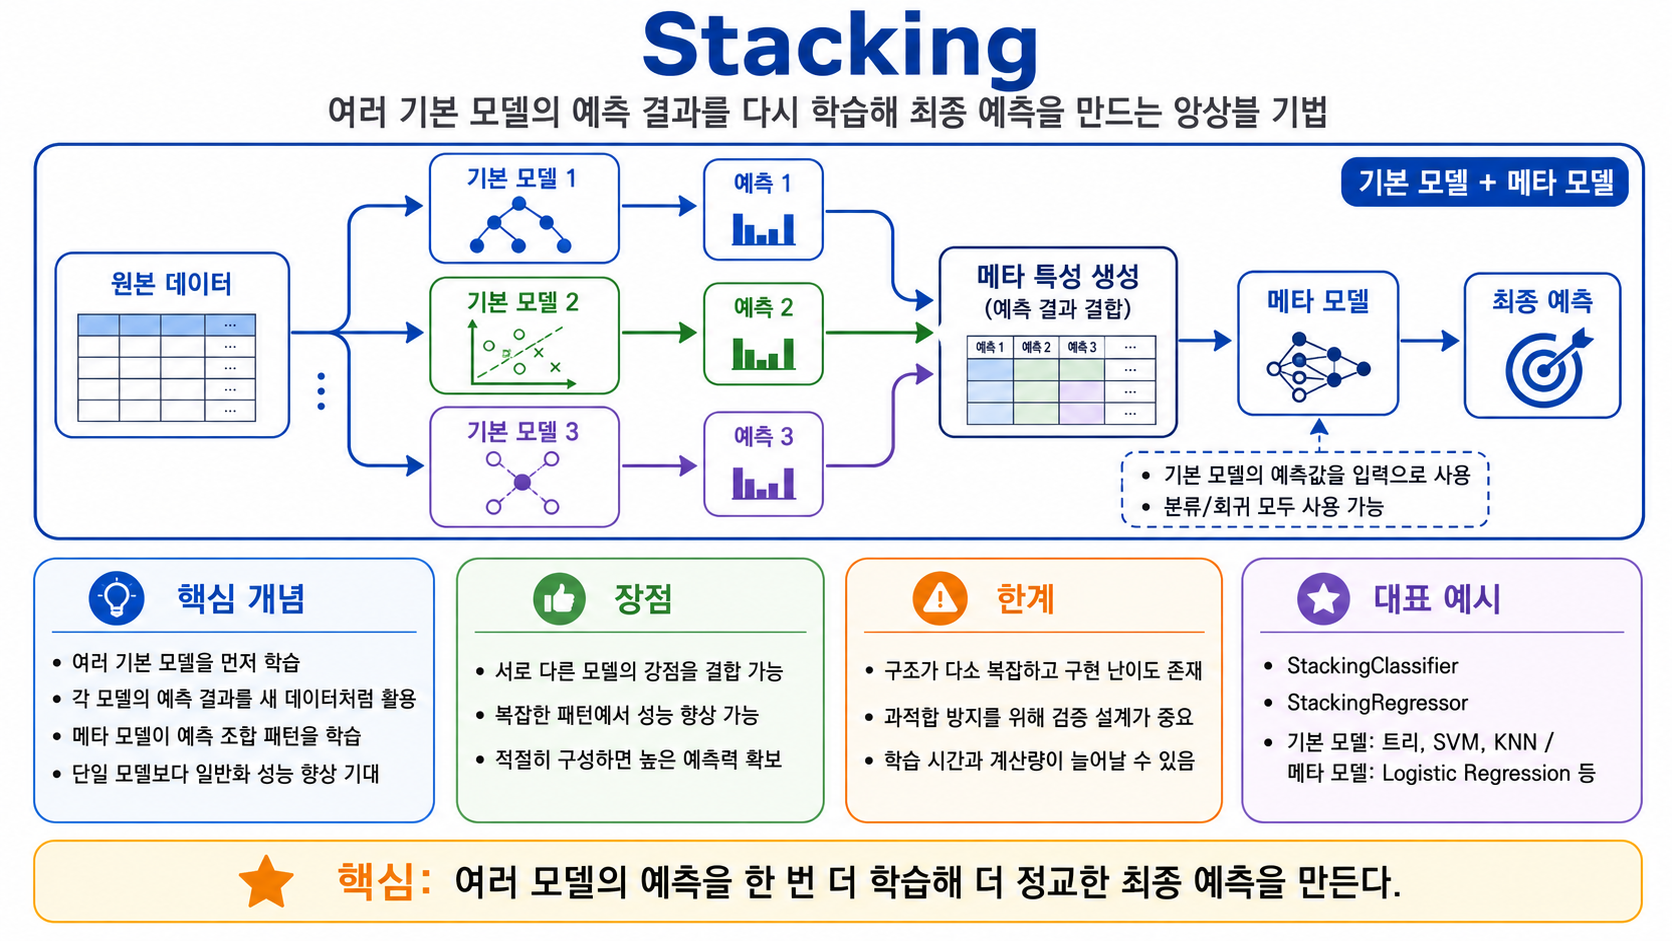

### 01-01. 배우는 이유

- Voting보다 한 단계 더 발전된 앙상블 방식을 이해할 수 있음.
- 서로 다른 모델의 장점을 최종 모델이 학습하도록 만들 수 있음.
- Kaggle, 실무 모델링에서 여러 모델을 조합할 때 자주 사용되는 아이디어임.

### 01-02. 어디서 사용하는가?

- 여러 모델의 성능이 비슷하지만 틀리는 샘플이 서로 다를 때 사용함.
- 최종 성능을 조금 더 끌어올리고 싶은 정형 데이터 모델링에서 자주 시도함.
- 분류와 회귀 모두 사용할 수 있으며, 모델 대회나 실무 앙상블 파이프라인에서 활용됨.

### 01-03. 동작 방식

1. 여러 기본 모델(base model)을 준비함.
2. 각 기본 모델이 예측값 또는 예측 확률을 만듦.
3. 이 예측 결과를 새로운 feature처럼 사용함.
4. 최종 모델(final estimator)이 이 예측 결과를 보고 최종 판단을 학습함.

### 01-04. Voting과 차이

**Voting**
- 예측값을 단순 투표하거나 평균냄.
- 결합 규칙이 비교적 단순함.

**Stacking**
- 기본 모델들의 예측을 최종 모델이 다시 학습함.
- 어떤 모델의 예측을 더 믿을지 데이터에서 학습할 수 있음.

### 01-05. 주의할 점

- 구조가 복잡해지고 계산량이 늘어날 수 있음.
- 기본 모델이 너무 비슷하면 Stacking 효과가 작을 수 있음.
- 내부 교차검증을 사용하므로 데이터가 너무 작을 때는 결과가 흔들릴 수 있음.


## 02. 실습 환경 준비

- `StackingClassifier`: 여러 분류 모델의 예측을 final estimator가 다시 학습함.
- `StackingRegressor`: 여러 회귀 모델의 예측값을 final estimator가 다시 학습함.
- Stacking은 내부 교차검증을 사용해 기본 모델의 예측을 만들기 때문에 단순 Voting보다 계산량이 더 많을 수 있음.


In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split

# Pipeline: 스케일링과 모델 학습을 하나의 흐름으로 묶음
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import classification_report, root_mean_squared_error, r2_score

# StackingClassifier: 기본 분류 모델들의 예측을 최종 모델이 다시 학습
# StackingRegressor: 기본 회귀 모델들의 예측값을 최종 모델이 다시 학습
from sklearn.ensemble import StackingClassifier, StackingRegressor


## 03. 분류 데이터 로드와 분리

- Breast Cancer 데이터를 사용해 Stacking 분류를 실습함.
- Logistic Regression과 KNN은 스케일링이 필요하므로 Pipeline 안에 `StandardScaler`를 포함함.
- Decision Tree는 스케일링이 필수는 아니지만 같은 Stacking 구조 안에서 함께 사용함.


In [2]:
cancer = load_breast_cancer(as_frame=True)
stack_X = cancer.data
stack_y = cancer.target

print('feature shape:', stack_X.shape)
print('target shape:', stack_y.shape)
print('target 이름:', cancer.target_names)
display(stack_X.head())


feature shape: (569, 30)
target shape: (569,)
target 이름: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
stack_X_train, stack_X_test, stack_y_train, stack_y_test = train_test_split(
    stack_X,
    stack_y,
    test_size=0.2,       # 전체 데이터의 20%를 평가 데이터로 분리
    random_state=42,     # 수업 중 같은 분할 결과가 나오도록 고정
    stratify=stack_y     # class 비율이 train/test에 비슷하게 유지되도록 분할
)

print('학습 데이터:', stack_X_train.shape, stack_y_train.shape)
print('평가 데이터:', stack_X_test.shape, stack_y_test.shape)

학습 데이터: (455, 30) (455,)
평가 데이터: (114, 30) (114,)


## 04. StackingClassifier 모델 구성

- `estimators`에는 기본 모델 목록을 넣음.
- `final_estimator`는 기본 모델들의 예측을 받아 최종 판단을 학습함.
- `cv`는 기본 모델의 예측을 만들 때 내부적으로 사용할 교차검증 fold 수임.


In [4]:
base_classifiers = [
    (
        'logistic_regression',
        Pipeline([
            # LogisticRegression은 feature 스케일 영향을 받을 수 있으므로 Pipeline 안에서 스케일링함.
            # Pipeline을 사용하면 cross validation 과정에서도 train fold에만 scaler가 fit되어 데이터 누수를 막을 수 있음.
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000))
        ])
    ),
    (
        'knn',
        Pipeline([
            # KNN은 거리 기반 모델이므로 feature 단위가 다르면 큰 숫자 feature가 판단을 지배할 수 있음.
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_neighbors=5))
        ])
    ),
    (
        'decision_tree',
        # DecisionTree는 feature의 대소 비교로 분기하므로 스케일링이 필수는 아님.
        # max_depth=4로 트리 복잡도를 제한해 과대적합을 줄임.
        DecisionTreeClassifier(max_depth=4, random_state=42)
    )
]

# StackingClassifier()
# - 기본 모델들의 예측 결과를
#   최종 모델(final estimator)이 학습하는 앙상블 모델
stacking_clf = StackingClassifier(
    estimators = base_classifiers, # 기본 모델들
    final_estimator = LogisticRegression(max_iter=1000),
    cv = 5, # 교차 검증 5회
    n_jobs = 1
)


## 05. 개별 모델과 StackingClassifier 비교

- Stacking이 항상 개별 모델보다 좋은 것은 아님.
- 중요한 것은 같은 train/test 데이터에서 공정하게 비교하는 것임.
- 평가 점수와 분류 리포트를 함께 확인함.


In [6]:
# 앞서 만든 분류 모델을 하나의 dict에 저장
classification_models = dict(base_classifiers)
classification_models['stacking'] = stacking_clf

stacking_results = []

for name, model in classification_models.items():

    # 학습
    model.fit(stack_X_train, stack_y_train)

    # 평가 결과를 stacking_results에 추가
    stacking_results.append({
        'model' : name,
        '학습셋 accuracy' : model.score(stack_X_train, stack_y_train),
        '평가셋 accuracy' : model.score(stack_X_test, stack_y_test),
    })

stacking_result_df = pd.DataFrame(stacking_results)
display(stacking_result_df)

# Stacking 모델의 class(정답)별 성능 확인
stack_y_pred = stacking_clf.predict(stack_X_test)
print(classification_report(stack_y_test, stack_y_pred))


,model,학습셋 accuracy,평가셋 accuracy
0,logistic_regression,0.989011,0.982456
1,knn,0.973626,0.956140
2,decision_tree,0.986813,0.938596
3,stacking,0.991209,0.982456


              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 06. Stacking 예측 결과 확인

- 같은 샘플에 대해 개별 모델과 Stacking 모델의 예측을 비교함.
- Stacking의 최종 예측은 단순 다수결이 아니라 final estimator가 학습한 규칙에 따라 결정됨.


In [7]:
sample_X = stack_X_test.iloc[:5]

prediction_table = pd.DataFrame({
    # actual: 실제 정답 class
    'actual': stack_y_test.iloc[:5].to_numpy(),

    # 아래 세 컬럼은 기본 모델들이 각각 단독으로 예측한 class임.
    'logistic_regression': classification_models['logistic_regression'].predict(sample_X),
    'knn': classification_models['knn'].predict(sample_X),
    'decision_tree': classification_models['decision_tree'].predict(sample_X),

    # stacking: 기본 모델 예측을 최종 모델이 조합해 만든 최종 class임.
    'stacking': stacking_clf.predict(sample_X)
})

display(prediction_table)

,actual,logistic_regression,knn,decision_tree,stacking
0,0,0,0,0,0
1,1,1,1,1,1
2,0,0,0,0,0
3,1,1,0,1,1
4,0,0,0,0,0


## 07. StackingRegressor 회귀 예측

- Stacking은 회귀에서도 사용할 수 있음.
- 기본 회귀 모델들의 숫자 예측값을 final estimator가 다시 학습함.
- 여기서는 Diabetes 데이터로 개별 회귀 모델과 StackingRegressor를 비교함.


In [8]:
diabetes = load_diabetes(as_frame=True)
reg_X = diabetes.data
reg_y = diabetes.target

print('feature shape:', reg_X.shape)
print('target shape:', reg_y.shape)
display(reg_X.head())


feature shape: (442, 10)
target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [9]:
reg_X_train, reg_X_test, reg_y_train, reg_y_test = train_test_split(
    reg_X,
    reg_y,
    test_size=0.2,
    random_state=42
)

print('회귀 데이터:', reg_X.shape, reg_y.shape)

회귀 데이터: (442, 10) (442,)


In [10]:
base_regressors = [
    (
        'ridge',
        Pipeline([('scaler', StandardScaler()),
                  ('model', Ridge())])
    ),
    (
        'knn_regressor',
        Pipeline([('scaler', StandardScaler()),
                  ('model', KNeighborsRegressor(n_neighbors=5))])
    ),
    (
        'decision_tree_regressor',
        DecisionTreeRegressor(max_depth=4, random_state=42)
    )
]


stacking_reg = StackingRegressor(
    estimators = base_regressors, # 기본 모델
    final_estimator = Ridge(),   # 최종 모델
    cv = 5,  # 교차 검증 5회
    n_jobs = 1 # 병렬 처리 X
)

# 개별 모델과 StackingRegressor를 같은 표에서 비교하기 위해 dict로 묶음.
regression_models = dict(base_regressors)
regression_models['stacking_regressor'] = stacking_reg

regression_results = []
for name, model in regression_models.items():
    model.fit(reg_X_train, reg_y_train)
    pred = model.predict(reg_X_test)

    regression_results.append({
        'model': name,
        # R2는 1에 가까울수록 평균 예측보다 모델 설명력이 좋다는 뜻임.
        'test_R2': r2_score(reg_y_test, pred),
        # RMSE는 예측 오차의 평균적인 크기이며 낮을수록 좋음.
        'test_RMSE': root_mean_squared_error(reg_y_test, pred)
    })

regression_result_df = pd.DataFrame(regression_results).sort_values('test_RMSE')
display(regression_result_df)

,model,test_R2,test_RMSE
3,stacking_regressor,0.460818,53.447806
0,ridge,0.454147,53.777454
1,knn_regressor,0.424809,55.203713
2,decision_tree_regressor,0.326375,59.740817


## 08. Stacking 정리

- Stacking은 기본 모델들의 예측을 최종 모델이 다시 학습하는 앙상블 방식임.
- Voting은 단순 투표/평균, Stacking은 예측 결과를 다시 학습한다는 차이가 있음.
- Stacking은 모델이 다양할수록 의미가 커질 수 있음.
- 내부 교차검증을 사용하므로 계산량이 늘어날 수 있음.
- 성능이 항상 좋아지는 것은 아니므로 개별 모델과 반드시 비교해야 함.
